In [1]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, clear_output
from ipywidgets import Button
import json
import numpy as np
import time
from shapely.geometry import Point, Polygon


In [2]:
fnnm=r'/Users/loukia/UCL Dropbox/Loukia Katsouri/VideosForJulijaObject/1119724_Loc15min_TEST_20230725_150248519downsampledcropped.mp4'
num_of_objects=2

In [3]:
def calculate_average_frame(video_path, num_frames=100):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.sort(random.sample(range(np.min([total_frames,6000])), num_frames))
    print(frame_indices)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
        else:
            print(f"Warning: Could not read frame at index {idx}")

    cap.release()
    frames_array = np.array(frames, dtype=np.float32)
    average_frame = np.mean(frames_array, axis=0).astype(np.uint8)
    average_frame = cv2.cvtColor(average_frame, cv2.COLOR_BGR2GRAY)
    return average_frame

# def onclick(event):
#     global ix, iy, points, last_point
#     ix, iy = event.xdata, event.ydata
#     points.append((ix, iy))

#     if last_point is not None:
#         # Draw a line from the last point to the current point
#         ax.plot([last_point[0], ix], [last_point[1], iy], color='red')
#         fig.canvas.draw()

#     last_point = (ix, iy)

#     return points

# Click event handler
def onclick(event):
    global ix, iy, points, last_point
    ix = event.xdata
    iy = event.ydata
    if ix is not None and iy is not None:  # Check if the click is within the plot
        points.append((ix, iy))

        if last_point is not None:
            # Draw a line from the last point to the current point
            ax.plot([last_point[0], ix], [last_point[1], iy], color='red')
            fig.canvas.draw()

        last_point = (ix, iy)

    return points

def disconnect():
    fig.canvas.mpl_disconnect(cid)
    plt.close(fig)
    print("Points:", points)
    
def average_close_points(points, max_distance=4):
    n = len(points)
    new_points = points.copy()
    for i in range(n):
        for j in range(i + 1, n):
            if np.linalg.norm(np.array(points[i]) - np.array(points[j])) <= max_distance:
                avg_x = (points[i][0] + points[j][0]) / 2
                avg_y = (points[i][1] + points[j][1]) / 2
                new_points[i] = (avg_x, avg_y)
                new_points[j] = (avg_x, avg_y)
    return new_points

In [4]:
%%time

average_frame = calculate_average_frame(fnnm)


[   4   10   12   31   93  193  237  344  370  376  469  492  513  523
  547  601  644  646  656  685  709  733  769  912  944  976 1026 1028
 1037 1086 1331 1392 1548 1579 2006 2012 2080 2140 2253 2298 2404 2464
 2479 2556 2563 2759 2783 2799 2806 2821 2827 2854 2899 2948 3045 3065
 3169 3196 3216 3228 3259 3376 3456 3519 3534 3547 3557 3568 3573 3801
 3807 3912 3990 4106 4118 4257 4346 4502 4743 4810 4812 4827 4850 4943
 4958 5153 5207 5217 5249 5337 5353 5556 5560 5586 5655 5667 5813 5900
 5977 5980]
CPU times: user 6.03 s, sys: 1.51 s, total: 7.54 s
Wall time: 1.25 s


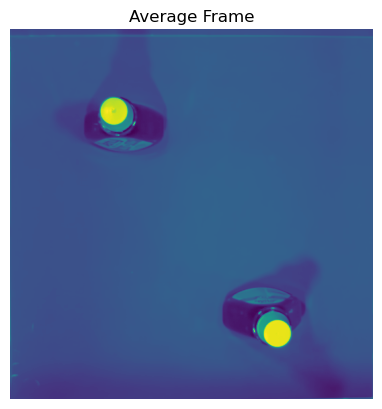

In [5]:
plt.imshow(average_frame)
plt.title('Average Frame')
plt.axis('off')
plt.show()

Button(description='Done', style=ButtonStyle())

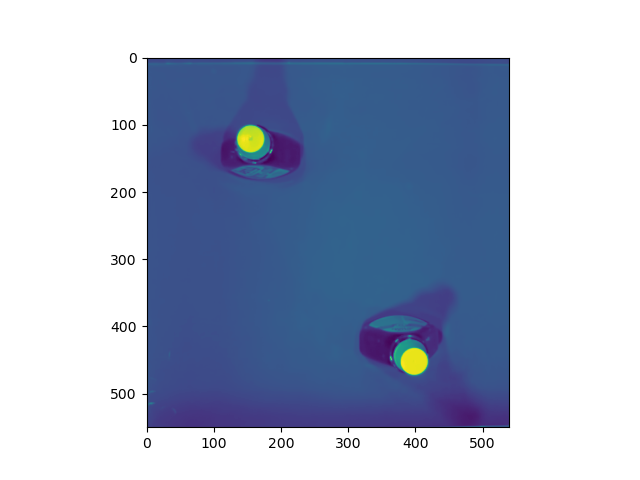

In [6]:
%matplotlib widget
fig, ax = plt.subplots(1,1)
ax.imshow(average_frame)
ax.set_xlim(0, average_frame.shape[1])
ax.set_ylim(average_frame.shape[0], 0)
points = []
last_point = None
cid = fig.canvas.mpl_connect('button_press_event', onclick)
# display(fig)
button = Button(description="Done")
button.on_click(lambda x: disconnect())
display(button)
points1=points
if points1:  # Ensure points1 is not empty before appending
    points1.append(points1[0])


Button(description='Done', style=ButtonStyle())

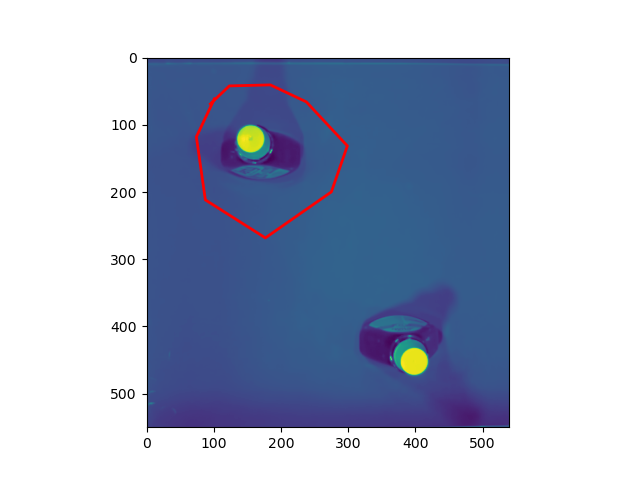

In [7]:
%matplotlib widget
fig, ax = plt.subplots(1,1)
ax.imshow(average_frame)
ax.set_xlim(0, average_frame.shape[1])
ax.set_ylim(average_frame.shape[0], 0)
x_coords, y_coords = zip(*points1)
ax.plot(x_coords, y_coords, color='red', linewidth=2)
points = []
last_point = None
cid = fig.canvas.mpl_connect('button_press_event', onclick)
# display(fig)
button = Button(description="Done")
button.on_click(lambda x: disconnect())
display(button)

# Initialize points2 to store new points
points2 = points
if points2:  # Ensure points2 is not empty before appending
    points2.append(points2[0])

In [8]:
print(points1)
print(points2)

[(100.89183625720793, 61.44951411655984), (74.10612197149365, 117.99713316417888), (87.49897911435076, 211.74713316417882), (176.78469340006504, 268.29475221179786), (274.99897911435073, 199.84237125941695), (298.8085029238746, 131.389990307036), (237.7965981619698, 65.9137998308455), (184.22516959054124, 40.61618078322647), (123.21326482863648, 42.104276021321766), (94.93945530482696, 68.88999030703599)]
[(352.37993149530314, 294.15558406284885), (257.14183625720796, 381.9532031104678), (277.9751695905412, 483.14367930094403), (432.73707435244603, 533.7389173961822), (527.9751695905412, 502.4889173961821), (514.5823124476841, 396.83415549142023), (480.3561219714936, 341.77463168189644), (330.0585029238746, 297.1317745390393)]


In [9]:
output_path='outtest.mp4'
outf1 = fnnm[:-4]+'_nice.mp4'
outf2 = fnnm[:-4]+'_select.mp4'
inside_1=np.array([])
inside_2=np.array([])

In [10]:
# Initialize the video capture
cap = cv2.VideoCapture(fnnm)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# Set up the video writers
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out1 = cv2.VideoWriter(outf1, fourcc, fps, (width, height))
out2 = cv2.VideoWriter(outf2, fourcc, fps, (width, height))

# Read the first frame
ret, prev_frame = cap.read()
ii=0

# Ensure points1 and points2 are defined
if 'points1' not in globals() or len(points1) == 0:
    points1 = [(0, 0), (width, 0), (width, height), (0, height), (0, 0)]  # Default to a full-frame polygon
if 'points2' not in globals() or len(points2) == 0:
    points2 = [(0, 0), (width, 0), (width, height), (0, height), (0, 0)]  # Default to a full-frame polygon

polygon1 = Polygon(points1)
polygon2 = Polygon(points2)


while True:
    try:
        ret, curr_frame = cap.read()
        subsequent_subtracted_frame = cv2.subtract(curr_frame, prev_frame)
    
        mask = subsequent_subtracted_frame > 20
        indices = np.column_stack(np.where(mask))

        if len(indices) > 0: # and len(indices) < 1000:
            mean_position = indices.mean(axis=0).astype(int)
#             mean_position_tuple = tuple(mean_position[:-1])
            mean_position_tuple = tuple([mean_position[1],mean_position[0]])  # (x, y) format for cv2
            point = Point(mean_position_tuple)

            if polygon1.contains(point):
                diameter = 10
                cv2.circle(curr_frame, mean_position_tuple, diameter // 2, (0, 255, 0), -1)
                out2.write(curr_frame)
                inside_1 = np.append(inside_1, ii)
            elif polygon2.contains(point):
                diameter = 10
                cv2.circle(curr_frame, mean_position_tuple, diameter // 2, (0, 0, 255), -1)
                out2.write(curr_frame)
                inside_2 = np.append(inside_2, ii)
            else:
                diameter = 5
                cv2.circle(curr_frame, mean_position_tuple, diameter // 2, (255, 0, 0), -1)
        # # Combine the results side by side for visualization (optional)
        # combined_frame = np.hstack((avg_subtracted_frame, subsequent_subtracted_frame))

        out1.write(curr_frame)

        prev_frame = curr_frame
        ii+=1
#         if ii > 1000:
#             break
    except Exception as e:
        print(f"An error occurred at frame {ii}: {e}") 
        break

    
cap.release()
out1.release()
out2.release()
print("Processing completed.")


An error occurred at frame 18334: OpenCV(4.9.0) /Users/xperience/GHA-OpenCV-Python2/_work/opencv-python/opencv-python/opencv/modules/core/src/arithm.cpp:650: error: (-209:Sizes of input arguments do not match) The operation is neither 'array op array' (where arrays have the same size and the same number of channels), nor 'array op scalar', nor 'scalar op array' in function 'arithm_op'

Processing completed.


In [46]:
tuple(mean_position[:-1])

(39, 149)

In [47]:
mean_position_tuple = tuple([mean_position[1],mean_position[0]])

mean_position_tuple

(149, 39)

In [48]:
mean_position

array([ 39, 149,   1])

In [35]:
print(indices[:20])


[[ 13 118   1]
 [ 13 118   2]
 [ 13 119   0]
 [ 13 119   1]
 [ 13 119   2]
 [ 13 120   0]
 [ 13 120   1]
 [ 13 120   2]
 [ 13 121   0]
 [ 13 121   1]
 [ 13 121   2]
 [ 13 122   1]
 [ 13 122   2]
 [ 13 123   1]
 [ 13 123   2]
 [ 13 124   0]
 [ 13 124   1]
 [ 13 124   2]
 [ 13 125   0]
 [ 13 125   2]]


In [49]:
print(indices[-20:])


[[ 83 174   2]
 [ 83 175   1]
 [ 83 175   2]
 [ 83 176   1]
 [ 83 176   2]
 [ 83 177   1]
 [ 83 177   2]
 [ 84 172   2]
 [ 84 173   1]
 [ 84 173   2]
 [ 84 174   1]
 [ 84 174   2]
 [ 84 175   1]
 [ 84 175   2]
 [ 84 176   1]
 [ 84 176   2]
 [ 84 177   2]
 [ 85 175   2]
 [ 85 176   1]
 [ 85 176   2]]


In [53]:
print(len(subsequent_subtracted_frame[:1]))

1


In [61]:
np.shape(subsequent_subtracted_frame)


(550, 540, 3)